# Thermal Expansion Coefficient of Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dipl_elasticity_modified.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dipl_NVT_NH_modified.c`

---

## Made some changes in C files

In 3dipl_elasticity.c
Instead of simulating each glass individually, modified it a bit to make it work in loop for all glass files;
Creates a txt file for results and contains simplified format for numbers which denotes; serial  pressure  u/N  G  K.

In 3dipl_NVT_NH.c
Same thing, made it work in loop;
Introduced pressure = 0.0 for resetting as I'm running a loop, so dont want Pressure to keep adding up with each loop for different glasses;

Assigned initial velocity, since we are talking about temperature not being zero, liquids will move, so need to assign initial velocity else it will be same as T=0, so the assigned velocity comes from Maxwell-Boltzmann distribution at that temperature.
normal(0.0, T) draws a random number from a Gaussian distribution with mean 0 and variance T. It does this independently for every atom, every direction. So after this loop, every atom has a random velocity assigned, some positive, some negative, small magnitudes for low T, larger for high T. What this assures is that system does not start from 0 velocity, which I think is important because, the glass positions loaded from the file are a T=0 inherent structure, atoms sitting exactly at their energy minimum, perfectly still. The moment we assign velocities and start the simulation, the atoms start vibrating around those positions. If we assign velocities correctly from the Maxwell-Boltzmann distribution at our target T, those vibrations immediately have the right amplitude and the system is already in the right thermodynamic state.
If we started from zero, the atoms would be still for the first few steps, then forces would slowly kick them into motion, and the system would take a long time to reach equilibrium during which the pressure readings are meaningless.

This approach seems more stable and less time taking than intended approach in original NVT_NH.c

Also, but in NVT_NH.c, it was calculating Pressure from only 2 dimensions, x and y, fixed it to 3 dimensions by adding term dz*dz. I noticed this after I plotted my graph, where elasticity's Pressure which is our initial point, was different from NVT_NH.c's initial point, but they were supposed to be same

---

Ran following to get the elasticity and nvt files
```bash
gcc -O2 -o elasticity 3dipl_elasticity.c -lm
gcc -O2 -o nvt        3dipl_NVT_NH.c     -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

It reads all 10 glass files automatically and writes **`elasticity_results.txt`**.

That file will look like:
```
# serial   pressure    u_per_N      G           K
0          5.6432...   -7.123...    12.34...    45.67...
1          ...
...
9          ...
```
---

## Running 'nvt' at several temperatures

We run it as:  `./nvt  <temperature>  <glass_number>`

For example `./nvt 0.01 3` runs glass #3 at T=0.01 and saves to `nvt_T0.0100_g3.dat`.

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about**, it is the pressure WITHOUT the kinetic term, exactly what the theory predicts.


---

## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                              
TEMPERATURES = [0.001, 0.003, 0.010, 0.030, 0.050]
GLASSES      = list(range(10))                  # 0 through 9
SKIP         = 0.3                              # discards first 30% of each trajectory as equilibration

## Load bulk modulus K from `elasticity_results.txt`

In [5]:
elas = np.loadtxt(Path(DATA_DIR) / 'elasticity_results.txt', comments='#')

# columns: serial  pressure  u_per_N  G  K
serials = elas[:, 0].astype(int)
P0      = elas[:, 1]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")

 Glass            P0           G           K
----------------------------------------------
     0     18.589542    14.85538    85.71690
     1     18.595402    14.71244    85.74152
     2     18.599067    15.08427    85.75715
     3     18.609666    14.70688    85.80236
     4     18.595036    14.76867    85.74001
     5     18.594715    14.39145    85.73756
     6     18.604564    14.51371    85.78128
     7     18.594242    15.05659    85.73714
     8     18.592544    14.83152    85.73131
     9     18.596734    14.58759    85.74740

Mean K  = 85.74926  (std = 0.02389)
Mean P0 = 18.597151


## Load NVT files and compute mean pressure at each temperature

In [6]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]          # production part only
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()   # T = (2/3) * mean(KE/N)
    P_mean = prod[:, 3].mean()                  # mean virial pressure
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))  # standard error
    return T_meas, P_mean, P_err


# collect results: for each temperature average over all 10 glasses
T_measured_list = []
P_mean_list     = []
P_err_list      = []

print(f"{'T_target':>10}  {'T_measured':>12}  {'mean P_vir':>12}  {'err':>10}  {'n_glasses':>10}")
print("-" * 62)

for T in TEMPERATURES:
    P_vals = []
    T_vals = []
    missing = []
    for g in GLASSES:
        f = Path(DATA_DIR) / f'nvt_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            P_vals.append(Pm)
            T_vals.append(Tm)
        else:
            missing.append(g)

    if missing:
        print(f"  T={T}: still missing glasses {missing}")

    if P_vals:
        T_avg = np.mean(T_vals)
        P_avg = np.mean(P_vals)
        # error = spread across glasses / sqrt(n) : captures sample-to-sample variation
        P_err = np.std(P_vals) / np.sqrt(len(P_vals)) if len(P_vals) > 1 else Pe
        T_measured_list.append(T_avg)
        P_mean_list.append(P_avg)
        P_err_list.append(P_err)
        print(f"{T:>10.4f}  {T_avg:>12.6f}  {P_avg:>12.6f}  {P_err:>10.2e}  {len(P_vals):>10}")

T_arr = np.array(T_measured_list)
P_arr = np.array(P_mean_list)
E_arr = np.array(P_err_list)

  T_target    T_measured    mean P_vir         err   n_glasses
--------------------------------------------------------------
    0.0010      0.000998     18.601251    1.78e-03          10
    0.0030      0.002994     18.609379    1.79e-03          10
    0.0100      0.009980     18.637525    1.70e-03          10
    0.0300      0.029936     18.718216    1.67e-03          10
    0.0500      0.049897     18.799100    1.44e-03          10


## Fit a line to P vs T → get ∂p/∂T

In [14]:
# weighted linear fit:  P(T) = intercept + slope * T
w    = 1.0 / E_arr**2
A    = np.column_stack([np.ones_like(T_arr), T_arr])
W    = np.diag(w)
M    = A.T @ W @ A
coeffs = np.linalg.solve(M, A.T @ W @ P_arr)
cov    = np.linalg.inv(M)
errs   = np.sqrt(np.diag(cov))

P0_fit     = coeffs[0]    # P extrapolated to T=0
dPdT       = coeffs[1]    # slope = ∂p/∂T
dPdT_err   = errs[1]

print(f"Fit:  P(T) = {P0_fit:.6f}  +  {dPdT:.5f} * T")
print()
print(f"∂p/∂T  =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print()
# sanity check: T=0 intercept from fit should match P0 from elasticity
disc = abs(P0_fit - P0_mean) / abs(P0_mean) * 100
print(f"Sanity check — P(T→0) from fit:      {P0_fit:.6f}")
print(f"              P0 from elasticity.c:   {P0_mean:.6f}")
print(f"              Discrepancy:             {disc:.6f}%  ← should be < 1%")

Fit:  P(T) = 18.597198  +  4.04549 * T

∂p/∂T  =  4.04549  ±  0.03787

Sanity check — P(T→0) from fit:      18.597198
              P0 from elasticity.c:   18.597151
              Discrepancy:             0.000253%  ← should be < 1%


## Compute α

Since I was asked to calculate alpha without kinetic term, we can safely ignore the "rho" which is also implementeed in C files.

In [8]:
alpha     = dPdT / K_mean

# simple error propagation
alpha_err = abs(alpha) * np.sqrt((dPdT_err/dPdT)**2 + (K_std/K_mean)**2)

print("Result")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α = (1/K)(∂p/∂T) =  {alpha:.5f}  ±  {alpha_err:.5f}")

Result
  K          =  85.74926  ±  0.02389
  ∂p/∂T|_V   =  4.04549  ±  0.03787
  α = (1/K)(∂p/∂T) =  0.04718  ±  0.00044



## Again, virial pressure (not total pressure)?

Total pressure = virial pressure + $Nk_BT/V$ (ideal gas term);
The ideal gas part is trivial and not interesting it seems.  
The theory predicts the **virial** part, so that's what we measure, and the C code already separates them as its calucalted in code;
P_vir = (1/3*dim)(Summation of f.r)

## Check that the fit is actually linear (not curved)

In [9]:
# residuals in units of error bars (should all be near zero)
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr

print("Residuals (how many σ each point is away from the fit line):")
print(f"{'T':>8}  {'residual':>10}")
for T, r in zip(T_arr, residuals):
    flag = '  ← large! may be outside linear regime' if abs(r) > 3 else ''
    print(f"{T:>8.4f}  {r:>+10.2f}σ{flag}")


Residuals (how many σ each point is away from the fit line):
       T    residual
  0.0010       +0.01σ
  0.0030       +0.04σ
  0.0100       -0.03σ
  0.0299       -0.05σ
  0.0499       +0.03σ


If its high then there's a problem

## Plots

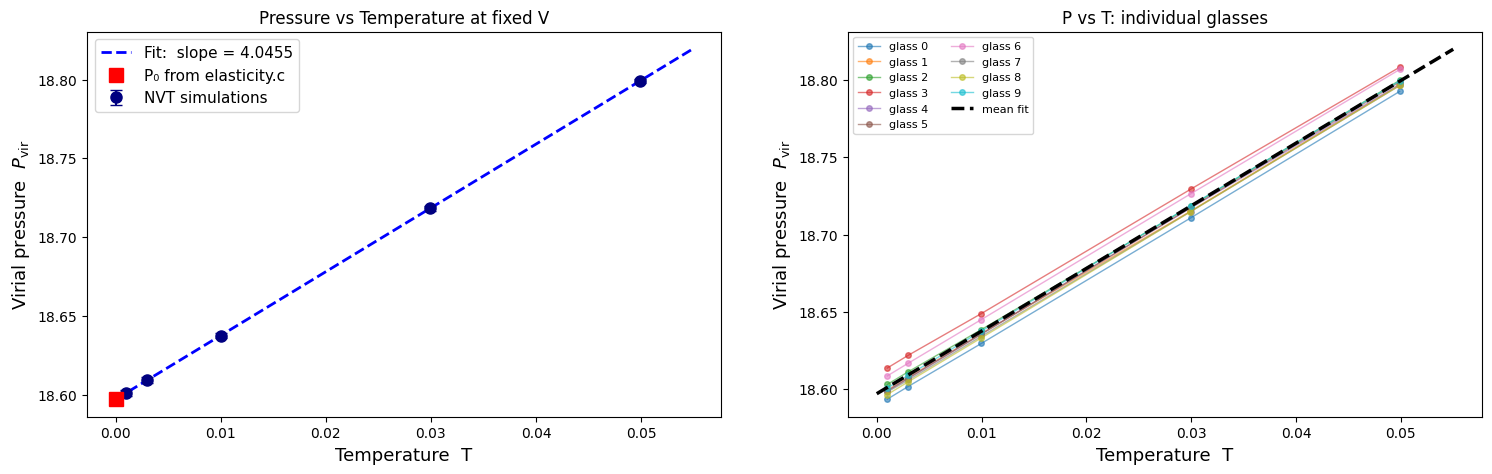

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#left: P_virial vs T
ax = axes[0]
ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
            markersize=8, capsize=4, label='NVT simulations')

T_line = np.linspace(0, T_arr.max() * 1.1, 300)
ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
        label=f'Fit:  slope = {dPdT:.4f}')
ax.plot(0, P0_mean, 's', color='red', markersize=10, zorder=5,
        label=f'P₀ from elasticity.c')

ax.set_xlabel('Temperature  T', fontsize=13)
ax.set_ylabel('Virial pressure  $P_\\mathrm{vir}$', fontsize=13)
ax.set_title('Pressure vs Temperature at fixed V')
ax.legend(fontsize=11)

ax2 = axes[1]

for g in GLASSES:
    P_vals_this_glass = []
    T_vals_this_glass = []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals_this_glass.append(Tm)
            P_vals_this_glass.append(Pm)
    if P_vals_this_glass:
        ax2.plot(T_vals_this_glass, P_vals_this_glass,
                 'o-', lw=1, markersize=4, alpha=0.6, label=f'glass {g}')

# overlay the mean fit
T_line = np.linspace(0, max(TEMPERATURES)*1.1, 300)
ax2.plot(T_line, P0_fit + dPdT * T_line, 'k--', lw=2.5, label='mean fit')

ax2.set_xlabel('Temperature  T', fontsize=13)
ax2.set_ylabel('Virial pressure  $P_\\mathrm{vir}$', fontsize=13)
ax2.set_title('P vs T: individual glasses')
ax2.legend(fontsize=8, ncol=2)

In [11]:
from pathlib import Path
import numpy as np
print("        THERMAL EXPANSION ANALYSIS — FULL SUMMARY")

# Per-glass elastic properties
print("\nElastic Properties (from elasticity.c)")
print(f"{'Glass':>6}  {'P₀ (virial)':>14}  {'G (shear)':>12}  {'K (bulk)':>12}")
print("─" * 50)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>14.6f}  {G[i]:>12.5f}  {K[i]:>12.5f}")
print("─" * 50)
print(f"{'Mean':>6}  {P0_mean:>14.6f}  {G.mean():>12.5f}  {K_mean:>12.5f}")
print(f"{'Std':>6}  {P0.std():>14.6f}  {G.std():>12.5f}  {K_std:>12.5f}")

#NVT pressure measurements
print("\nNVT Pressure at Each Temperature (averaged over 10 glasses)")
print(f"{'T_target':>10}  {'T_measured':>12}  {'⟨P_vir⟩':>12}  {'std_err':>10}")
print("─" * 50)
for T_tgt, T_m, P_m, P_e in zip(TEMPERATURES, T_arr, P_arr, E_arr):
    print(f"{T_tgt:>10.4f}  {T_m:>12.6f}  {P_m:>12.6f}  {P_e:>10.2e}")

#Linear fit results
print("\nLinear Fit:  P_vir(T) = P₀_fit + (∂p/∂T)·T")
print(f"  P₀  (fit intercept)  =  {P0_fit:>12.6f}")
print(f"  P₀  (from elasticity)=  {P0_mean:>12.6f}   discrepancy: {disc:.2f}%")
print(f"  ∂p/∂T|_V             =  {dPdT:>12.5f}  ±  {dPdT_err:.5f}")

#Residuals
print("\nFit Residuals (should all be |r| < 3σ)")
print(f"{'T_measured':>12}  {'residual':>12}")
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr
#Final result
print("  RESULT:  α = (1/K) · (∂p/∂T)|_V")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α          =  {alpha:.5f}  ±  {alpha_err:.5f}")


        THERMAL EXPANSION ANALYSIS — FULL SUMMARY

Elastic Properties (from elasticity.c)
 Glass     P₀ (virial)     G (shear)      K (bulk)
──────────────────────────────────────────────────
     0       18.589542      14.85538      85.71690
     1       18.595402      14.71244      85.74152
     2       18.599067      15.08427      85.75715
     3       18.609666      14.70688      85.80236
     4       18.595036      14.76867      85.74001
     5       18.594715      14.39145      85.73756
     6       18.604564      14.51371      85.78128
     7       18.594242      15.05659      85.73714
     8       18.592544      14.83152      85.73131
     9       18.596734      14.58759      85.74740
──────────────────────────────────────────────────
  Mean       18.597151      14.75085      85.74926
   Std        0.005626       0.20925       0.02389

NVT Pressure at Each Temperature (averaged over 10 glasses)
  T_target    T_measured       ⟨P_vir⟩     std_err
─────────────────────────────────